In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers')
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/EMIP-Toolkit', '/content/drive/MyDrive/EMIP-Toolkit/emtk', '/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers']


In [3]:
import parsers
import aoi
import visualization
import util

In [4]:
import os
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'

os.chdir(desired_path)
print(os.getcwd())

#eye_events, samples = parsers.EMIP(sample_size = 50)
eye_events, samples = parsers.EMIP(sample_size = 10)

/content/drive/MyDrive/EMIP-Toolkit
emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/emip_metadata.csv
Loaded metadata for 216 participants
Gender mapping created for 216 participants
{'1': 'male', '2': 'male', '3': 'female', '4': 'male', '5': 'male', '6': 'male', '7': 'male', '8': 'female', '9': 'male', '10': 'male', '11': 'male', '12': 'female', '13': 'female', '14': 'male', '15': 'male', '16': 'male', '17': 'male', '18': 'female', '19': 'female', '20': 'male', '21': 'male', '22': 'male', '23': 'male', '24': 'male', '25': 'male', '26': 'male', '27': 'male', '28': 'male', '29': 'male', '30': 'male', '31': 'male', '32': 'male', '33': 'male', '34': 'male', '35': 'male', '36': 'female', '37': 'male', '38': 'male', '39': 'female', '40': 'male', '41': 'male', '42': 'male', '43': 'male', '44': 'male', '45': 'male', '46': 'male', '47': 'male', '48': 'male', '49': 'male', '50': 'male', '51': 'male', '52': 'male', '53': 'male', '54': 'male', '55': 'male', '56': 'male', '57': '

/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers/EMIP.py:94: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  samples_df = samples_df.apply(pd.to_numeric, errors='ignore')


#TODO: REmove Downgrade Pandas and Numpy  - NOT WORKING IN PYTHON 3.12!!

In [ ]:
#!pip uninstall pandas -y
#!pip install pandas==1.5.3
#!pip install pandas==2.2.2

In [5]:
!python --version
#!pip uninstall numpy -y
#!pip install numpy==1.23.5
#!python -m venv env
#!source env/bin/activate
#!pip install numpy==1.26.0

Python 3.12.11


# - TODO: Remove from NOTEBOOK Parsing raw data from the EMIP dataset

In [26]:
import pandas as pd
import os

desired_path = '/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers'

os.chdir(desired_path)
print(os.getcwd())

from eye_events import eye_event_list, get_eye_event_columns
from samples import get_samples_columns, samples_list

from emtk.fixation_classification import idt_classifier

/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers


## Read gender from the metadata file


In [27]:
# Set the working directory path to the directory containing the participants meta data
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)
print(os.getcwd())

entries = os.listdir(os.getcwd())
print(entries)



/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset
['date.txt', 'emip_metadata.csv', 'stimuli', 'rawdata', 'EMIP_DataCollection_Materials', 'emip_eye_events.csv', 'emip_samples.csv', 'emip_eye_events.gsheet']


In [28]:
from collections import Counter
# Load metadata
#METADATA_FILE = '/emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/emip_metadata.csv'
METADATA_FILE = 'emip_metadata.csv'
try:
    metadata_df = pd.read_csv(METADATA_FILE)
    print(f"Loaded metadata for {len(metadata_df)} participants")

    # Create a mapping from participant ID to gender
    # Assuming'id' column in metadata corresponds to experiment_id/participant_id
    gender_mapping = dict(zip(metadata_df['id'].astype(str), metadata_df['gender']))
    print(f"Gender mapping created for {len(gender_mapping)} participants")
    print(gender_mapping)
    gender_counts = Counter(gender_mapping.values())
    print(f"Males: {gender_counts.get('male', 0)}")
    print(f"Females: {gender_counts.get('female', 0)}")


except FileNotFoundError:
    print(f"Warning: Metadata file '{METADATA_FILE}' not found. Gender will be set to Male.")
    gender_mapping = {}
except Exception as e:
    print(f"Error loading metadata: {e}. Gender will be set to Male.")
    gender_mapping = {}

Loaded metadata for 216 participants
Gender mapping created for 216 participants
{'1': 'male', '2': 'male', '3': 'female', '4': 'male', '5': 'male', '6': 'male', '7': 'male', '8': 'female', '9': 'male', '10': 'male', '11': 'male', '12': 'female', '13': 'female', '14': 'male', '15': 'male', '16': 'male', '17': 'male', '18': 'female', '19': 'female', '20': 'male', '21': 'male', '22': 'male', '23': 'male', '24': 'male', '25': 'male', '26': 'male', '27': 'male', '28': 'male', '29': 'male', '30': 'male', '31': 'male', '32': 'male', '33': 'male', '34': 'male', '35': 'male', '36': 'female', '37': 'male', '38': 'male', '39': 'female', '40': 'male', '41': 'male', '42': 'male', '43': 'male', '44': 'male', '45': 'male', '46': 'male', '47': 'male', '48': 'male', '49': 'male', '50': 'male', '51': 'male', '52': 'male', '53': 'male', '54': 'male', '55': 'male', '56': 'male', '57': 'male', '58': 'male', '59': 'female', '60': 'male', '61': 'male', '62': 'male', '63': 'male', '64': 'male', '65': 'female

In [21]:
# Replace this path with the directory containing the emtk folder
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'

os.chdir(desired_path)
print(os.getcwd())


/content/drive/MyDrive/EMIP-Toolkit


In [24]:
RAWDATA_MODULE = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/rawdata"

SAMPLE_BASE_COLUMNS = ['Time', 'Type', 'Trial', 'L Raw X [px]', 'L Raw Y [px]', 'R Raw X [px]',
                       'R Raw Y [px]', 'L Dia X [px]', 'L Dia Y [px]', 'L Mapped Diameter [mm]',
                       'R Dia X [px]', 'R Dia Y [px]', 'R Mapped Diameter [mm]', 'L CR1 X [px]',
                       'L CR1 Y [px]', 'L CR2 X [px]', 'L CR2 Y [px]', 'R CR1 X [px]', 'R CR1 Y [px]',
                       'R CR2 X [px]', 'R CR2 Y [px]', 'L POR X [px]', 'L POR Y [px]', 'R POR X [px]',
                       'R POR Y [px]', 'Timing', 'L Validity', 'R Validity', 'Pupil Confidence',
                       'L Plane', 'R Plane', 'L EPOS X', 'L EPOS Y', 'L EPOS Z', 'R EPOS X', 'R EPOS Y',
                       'R EPOS Z', 'L GVEC X', 'L GVEC Y', 'L GVEC Z', 'R GVEC X', 'R GVEC Y',
                       'R GVEC Z', 'Frame', 'Aux1']

def EMIP(sample_size: int = 216):
    """Import the EMIP dataset.

    Parameters
    ----------
    sample_size : int, optional (default 216)
        Number of subjects to be processed.

    Returns
    -------
    pandas.DataFrame
        Pandas dataframe of eye events from every experiment in the dataset.
    """
    eye_events = []
    samples = []
    parsed_experiments = []

    # go over .tsv files in the rawdata directory add files and count them
    # r = root, d = directories, f = files
    for r, _, f in os.walk(RAWDATA_MODULE):
        f = [name for name in f if name and name[0].isdigit()]
        print(len(f))
        #f.sort()
        f.sort(key=lambda name: int(name.split('_')[0]))
        for file in f:
            if '.tsv' in file:
                experiment_id = file.split('/')[-1].split('_')[0] #Experiment_id refers to participant ID

                if experiment_id not in parsed_experiments:
                    parsed_experiments.append(experiment_id)

                    #Get gender for this participant
                    participant_gender = gender_mapping.get(experiment_id, None)
                    if participant_gender is None:
                        print(f"Warning: No gender data found for participant {experiment_id}")
                        participant_gender = "male"
                    else:
                        print(f"Gender for participant {experiment_id}: {participant_gender}")


                    new_eye_events, new_samples = read_SMIRed250(
                        root_dir=r,
                        filename=file,
                        experiment_id=experiment_id,
                        gender = participant_gender
                    )

                    eye_events.extend(new_eye_events)
                    samples.extend(new_samples)

                else:
                    print("Error, experiment already in dictionary")

            sample_size -= 1
            if sample_size == 0:
                break

    eye_events_df = pd.DataFrame(eye_events, columns=get_eye_event_columns())

    # Convert columns with numbers formatted as strings to dtype of numeric
    samples_df = pd.DataFrame(
        samples, columns=get_samples_columns(SAMPLE_BASE_COLUMNS))
    id_dfs = samples_df[["experiment_id", "participant_id", "trial_id"]]
    samples_df = samples_df.apply(pd.to_numeric, errors='ignore')
    samples_df[id_dfs.columns] = id_dfs

    return eye_events_df, samples_df

In [58]:
EYE_TRACKER = "SMIRed250"
FILE_TYPE = ".tsv"
STIMULI_MODULE = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/stimuli"

def read_SMIRed250(root_dir, filename, experiment_id,
                   minimum_duration=50, sample_duration=4, maximum_dispersion=25, gender = None) -> list:
    """Read tsv file from SMI Red 250 eye tracker

    Parameters
    ----------
    root_dir : str
        Path to directory that contains the asc file.

    filename : str
        Name of asc file.

    experiment_id : str
        Id of the experiment contained in the file.

    Returns
    -------
    list
        List of eye events. Each eye event is represented as a list of eye event features.
    """

    # Reads raw data and sets up
    tsv_file = open(os.path.join(root_dir, filename))
    #print(filename)
    print("parsing file:", filename.split("/")[-1])
    text = tsv_file.read()
    text_lines = text.split('\n')

    trial_id = 0
    stimuli_name = ""
    raw_fixations = []
    active = False  # Indicates whether samples are being recorded in trials
    # The goal is to skip metadata in the file

    eye_events = []
    samples = []

    # Parses the data into dataframes
    for line in text_lines:
        token = line.split("\t")

        if len(token) < 3:
            continue

        if active:
            # Filter MSG samples if any exist, or R eye is inValid
            if token[1] == "SMP" and token[27] != "-1":
                # Get x and y for each sample (right eye only)
                # [23] R POR X [px]	 '0.00',
                # [24] R POR Y [px]	 '0.00',

                new_sample = samples_list(
                    eye_tracker=EYE_TRACKER,
                    experiment_id=experiment_id,
                    participant_id=experiment_id,
                    filename=filename,
                    trial_id=str(trial_id),
                    stimuli_module=STIMULI_MODULE,
                    stimuli_name=stimuli_name,
                    token=token,
                    gender = gender
                )

                samples.append(new_sample)

                raw_fixations.append(
                    [int(token[0]), float(token[23]), float(token[24])])

        if token[1] == "MSG" and token[3].find(".jpg") != -1:

            if active:
                filter_eye_events = idt_classifier(raw_fixations=raw_fixations,
                                                   minimum_duration=minimum_duration,
                                                   sample_duration=sample_duration,
                                                   maximum_dispersion=maximum_dispersion)
                # TODO saccades

                for timestamp, duration, x_cord, y_cord in filter_eye_events:

                    new_eye_event = eye_event_list(eye_tracker=EYE_TRACKER,
                                                   experiment_id=experiment_id,
                                                   participant_id=experiment_id,
                                                   filename=filename,
                                                   trial_id=str(trial_id),
                                                   stimuli_module=STIMULI_MODULE,
                                                   stimuli_name=stimuli_name,
                                                   duration=duration,
                                                   timestamp=timestamp,
                                                   x0=x_cord,
                                                   y0=y_cord,
                                                   token=token,
                                                   pupil=0,
                                                   eye_event_type="fixation",
                                                   gender = gender)

                    eye_events.append(new_eye_event)

                trial_id += 1

            # Message: vehicle_java2.jpg
            stimuli_name = token[3].split(' ')[-1]
            print(stimuli_name)
            raw_fixations = []
            active = True

    # Adds the last trial
    filter_fixations = idt_classifier(raw_fixations=raw_fixations,
                                      minimum_duration=minimum_duration,
                                      sample_duration=sample_duration,
                                      maximum_dispersion=maximum_dispersion)

    for timestamp, duration, x_cord, y_cord in filter_fixations:

        new_eye_event = eye_event_list(eye_tracker=EYE_TRACKER,
                                       experiment_id=experiment_id,
                                       participant_id=experiment_id,
                                       filename=filename,
                                       trial_id=str(trial_id),
                                       stimuli_module=STIMULI_MODULE,
                                       stimuli_name=stimuli_name,
                                       duration=duration,
                                       timestamp=timestamp,
                                       x0=x_cord,
                                       y0=y_cord,
                                       token=token,
                                       pupil=0,
                                       eye_event_type="fixation",
                                       gender = gender)

        eye_events.append(new_eye_event)

    print(trial_id)
    return eye_events, samples

# TODO- REMOVE  Load the data from the TSVs - sample size is configurable


In [ ]:
#eye_events, samples = EMIP(sample_size = 10)
eye_events, samples = EMIP(sample_size = 50)

In [5]:
samples.head()



,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,gender,Time,Type,...,R EPOS Y,R EPOS Z,L GVEC X,L GVEC Y,L GVEC Z,R GVEC X,R GVEC Y,R GVEC Z,Frame,Aux1
0,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,male,945553890,SMP,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,NaN
1,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,male,945557889,SMP,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,NaN
2,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,male,945561887,SMP,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,NaN
3,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,male,945565886,SMP,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,NaN
4,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,male,945569884,SMP,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,NaN


In [6]:
eye_events.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,x1,y1,token,pupil,amplitude,peak_velocity,eye_event_type,gender
0,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947253226,1652,0.000000,0.000000,NaN,NaN,"[1008043594, MSG, 1, # Message: instruction_co...",0,NaN,NaN,fixation,male
1,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947465143,200,0.000000,0.000000,NaN,NaN,"[1008043594, MSG, 1, # Message: instruction_co...",0,NaN,NaN,fixation,male
2,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947687475,204,0.000000,0.000000,NaN,NaN,"[1008043594, MSG, 1, # Message: instruction_co...",0,NaN,NaN,fixation,male
3,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,948493954,356,0.000000,0.000000,NaN,NaN,"[1008043594, MSG, 1, # Message: instruction_co...",0,NaN,NaN,fixation,male
4,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,948945831,72,811.589444,505.804444,NaN,NaN,"[1008043594, MSG, 1, # Message: instruction_co...",0,NaN,NaN,fixation,male


In [7]:
if eye_events.empty and samples.empty:
  print('Both eye_events and samples dataframes are empty')
else:
  print('Both eye_events and samples dataframes are not empty')

Both eye_events and samples dataframes are not empty


# **EXPORTING SAMPLES AND EYE EVENTS TO CSVs**

In [8]:
# Save the csv files in the emip_dataset folder
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)
print(os.getcwd())

entries = os.listdir(os.getcwd())
print(entries)

/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset
['date.txt', 'emip_metadata.csv', 'stimuli', 'rawdata', 'EMIP_DataCollection_Materials', 'emip_eye_events.csv', 'emip_samples.csv', 'emip_eye_events.gsheet']


In [9]:

try:
    # Define the filenames for the output files
    eye_events_output_file = 'emip_eye_events.csv'
    samples_output_file = 'emip_samples.csv'

    # Export the eye_events DataFrame
    print(f"Exporting eye events data to {eye_events_output_file}...")
    eye_events.to_csv(eye_events_output_file, index=False)
    print("Eye events export complete.")

    # Export the samples DataFrame
    print(f"\nExporting samples data to {samples_output_file}...")
    samples.to_csv(samples_output_file, index=False)
    print("Samples export complete.")

    print("\nBoth files have been successfully saved to your current directory.")

except NameError:
    print("Error: Make sure 'eye_events' and 'samples' exist before exporting.")
except Exception as e:
    print(f"An error occurred during export: {e}")

Exporting eye events data to emip_eye_events.csv...
Eye events export complete.

Exporting samples data to emip_samples.csv...
Samples export complete.

Both files have been successfully saved to your current directory.


# Test code - printing contents of data frames eye_events and samples


In [1]:
unique_participants = eye_events['participant_id'].unique()
print(unique_participants)

unique_participants = eye_events['gender'].unique()
print(unique_participants)

unique_participants = eye_events['eye_event_type'].unique()
print(unique_participants)

#pupil is intentionally set to zero here
unique_participants = eye_events['pupil'].unique()
print(unique_participants)

unique_participants = eye_events['trial_id'].unique()
print(unique_participants)

unique_participants = eye_events['duration'].unique()

NameError: name 'eye_events' is not defined

In [6]:
unique_participants = samples['participant_id'].unique()
print(unique_participants)

unique_participants = samples['gender'].unique()
print(unique_participants)


['1' '2' '3' '4' '5' '6' '7' '8' '9' '10']
['male' 'female']


# Read the corrected EMIP Dataset - append gender to it

In [29]:
import pandas as pd
import os

desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'Corrected EMIP Dataset'
)

os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP/EMIP-Toolkit- replication package/Corrected EMIP Dataset


In [30]:
CORRECTED_DATASET_FILE = 'finalset_line_part.csv'
try:
    corrected_df = pd.read_csv(CORRECTED_DATASET_FILE)
    participants = corrected_df['participant'].unique()
    print(f"Loaded corrected data set for {len(participants)} participants")

    corrected_df['gender'] = corrected_df['participant'].astype(str).map(gender_mapping)

    print(f"Loaded corrected data set with {len(corrected_df)} fixation points")

except FileNotFoundError:
    print(f"Warning: CSV file '{CORRECTED_DATASET_FILE}'not file")
except Exception as e:
    print(f"Error loading corrected dataset: {e}.")


Loaded corrected data set for 159 participants
Loaded corrected data set with 61799 fixation points


In [31]:
participants_with_gender = corrected_df[['participant', 'gender']].drop_duplicates()
participants_with_gender = participants_with_gender.sort_values('participant').reset_index(drop=True)
print(participants_with_gender)

     participant  gender
0              1    male
1              3  female
2              4    male
3              5    male
4              6    male
..           ...     ...
154          211  female
155          212    male
156          214    male
157          215    male
158          216  female

[159 rows x 2 columns]


In [ ]:
corrected_df.head()

In [32]:

temp_df = corrected_df[(corrected_df['participant'] == 1) & (corrected_df['code_file'] == 'vehicle_java.jpg') & (corrected_df['timestamp'].isin( [1020767309, 1021327250]))]

temp_df.head()


,Unnamed: 0,trial,participant,code_file,code_language,timestamp,duration,x_cord,y_cord,aoi_x,aoi_y,aoi_width,aoi_height,token,length,srcML,quality,line,part,gender
1556,1556,2,1,vehicle_java.jpg,vehicle_java.jpg,1020767309,84,836.736667,377.922381,732,374,189,18,this.currentSpeed,17,class->block->constructor->block->block_conten...,65,8,1,male
1557,1557,2,1,vehicle_java.jpg,vehicle_java.jpg,1021327250,100,705.422800,62.156000,689,57,54,18,class,5,class,65,1,2,male


In [19]:
code_files = corrected_df['code_file'].unique()
print(code_files)

code_files = corrected_df['code_language'].unique()
print(code_files)

['rectangle_java2.jpg' 'vehicle_java2.jpg' 'vehicle_java.jpg'
 'rectangle_java.jpg' 'rectangle_python.jpg' 'vehicle_python.jpg']
['rectangle_java2.jpg' 'vehicle_java2.jpg' 'vehicle_java.jpg'
 'rectangle_java.jpg' 'rectangle_python.jpg' 'vehicle_python.jpg']


#Basic statistical analysis

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

Using srcML tags to identify the the unique AOI and fixation duration.

In [21]:
aoi_types = corrected_df['srcML'].unique()
print(f"Analyzing {len(aoi_types)} AOIs: {aoi_types}\n")


results = {}
significant_aois = {}
for aoi in aoi_types:

    aoi_df = corrected_df[corrected_df['srcML'] == aoi]

    male_durations = aoi_df[aoi_df['gender'] == 'male']['duration'].dropna()
    female_durations = aoi_df[aoi_df['gender'] == 'female']['duration'].dropna()

    # Only perform the test if there is one male fixation and one female fixation available
    if len(male_durations) > 1 and len(female_durations) > 1:
        print(f"Analyzing male fixation durations {len(male_durations)} vs female {len(female_durations)} for AOI: {aoi}\n")
        stat, p_value = mannwhitneyu(male_durations, female_durations, alternative='two-sided')
        results[aoi] = {'statistic': stat, 'p_value': p_value, 'token_val': aoi_df['token'].astype(str) }
    else:
        results[aoi] = {'statistic': None, 'p_value': None, 'token_val': None }


# Print the statistical results
significant_count = 0
print("--- Statistical Test Results (Wilcoxon) ---")
for aoi, result in results.items():
    if result['p_value'] is not None:
        print(f"AOI: {aoi:<20} | P-value: {result['p_value']:.4f}", end="")
        if result['p_value'] < 0.05:
            significant_count += 1
            significant_aois[aoi] = result['token_val'].unique().tolist()
            print(f"The significant srcML is {aoi} and token is  {result['token_val'].unique().tolist()}")
            print(" (Statistically Significant)")
        else:
            print("")
    else:
        print(f"AOI: {aoi:<20} | Not enough data to compare.")

print(f"\n{significant_count} AOIs are statistically significant.")
#print(significant_aois)

for aoi, tokens in significant_aois.items():

        # Retrieve the corresponding p-value from the main 'results' dictionary
        p_value = results[aoi]['p_value']

        # Print the information in the desired format using an f-string
        print(f"The p-value is {p_value:.4f}, the list of tokens is {tokens}, and the sourceTag is {aoi}")



Analyzing 68 AOIs: ['class->block->constructor->block->block_content->expr_stmt->expr->operator'
 'class' 'class->name' 'class->specifier'
 'class->block->decl_stmt->decl->type->specifier'
 'class->block->constructor->name' 'class->block->function->type->name'
 'class->block->function->type->specifier'
 'class->block->constructor->block->block_content->expr_stmt->expr->name->name->operator->name'
 'class->block->decl_stmt->decl->name' 'class->block->decl_stmt'
 'class->block->constructor->specifier'
 'class->block->constructor->parameter_list->parameter->decl->type->name'
 'class->block->constructor->block->block_content->expr_stmt->expr->name->name'
 'class->block->function->name'
 'class->block->function->block->block_content->return->expr->name->name'
 'class->block->function->block->block_content->return'
 'class->block->function->block->block_content->return->expr->name->name->operator->name'
 'class->block->function->block->block_content->return->expr->operator'
 'class->block->f

# Visualization - Working now- NEED TO FIX - NOT WORKING AFTER UPDATES

In [7]:

desired_path = '/content/drive/MyDrive/EMIP-Toolkit'


os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit


#Raw data (samples), filtered fixations, saccades, and aoi

In [8]:
experiment_id = '1'   #Test code
trial_id = '2'

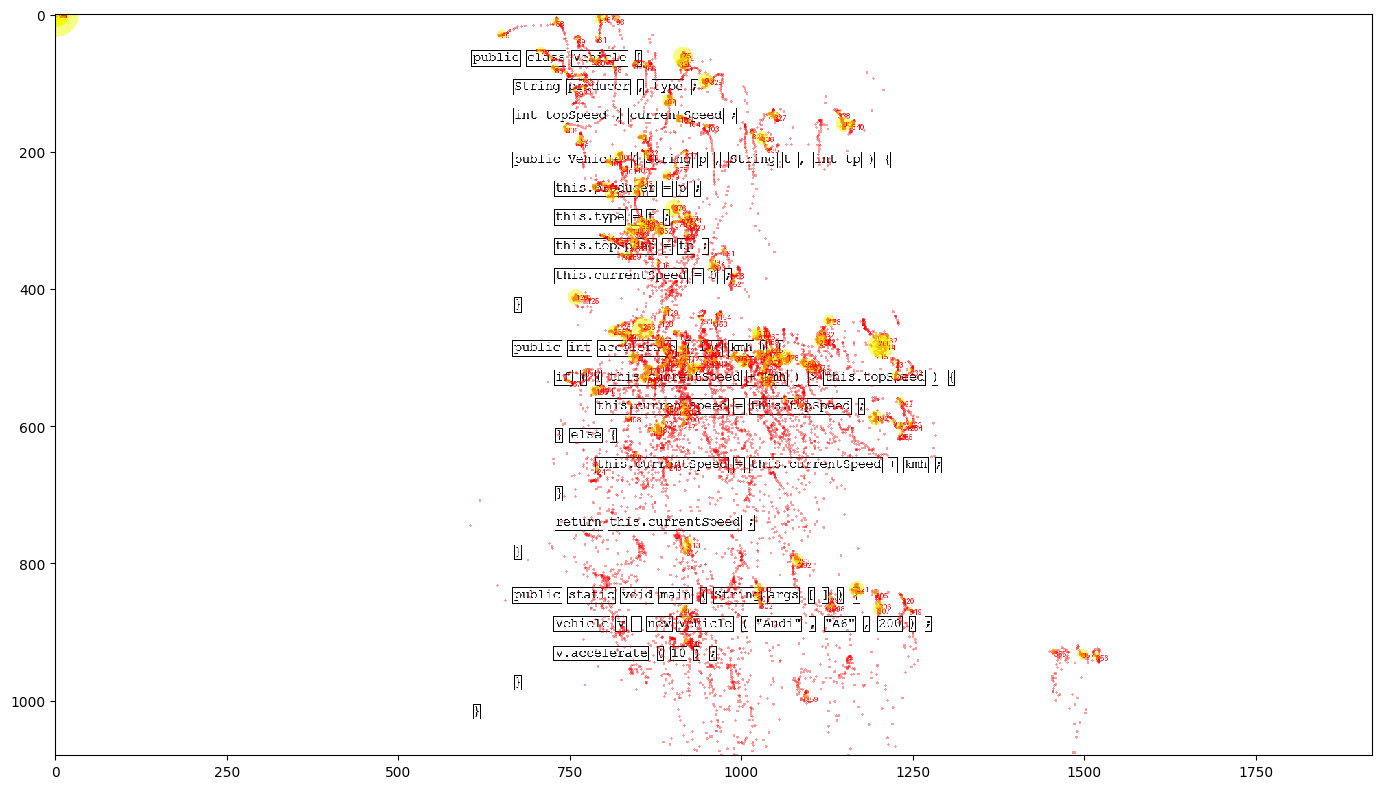

In [10]:
trial_data = eye_events.loc[(eye_events['experiment_id'] == experiment_id) &
                            (eye_events['trial_id'] == trial_id)]

samples_data = samples.loc[(samples['experiment_id'] == experiment_id) &
                            (samples['trial_id'] == trial_id)]

visualization.draw_trial(trial_data, samples_data, draw_raw_data = True, draw_aoi = True, draw_saccade=True,draw_number=True, sample_x_col="R POR X [px]", sample_y_col="R POR Y [px]")

/content/drive/MyDrive/EMIP-Toolkit/emtk/visualization/heatmap.py:62: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ax=ax, x=x_cords, y=y_cords,


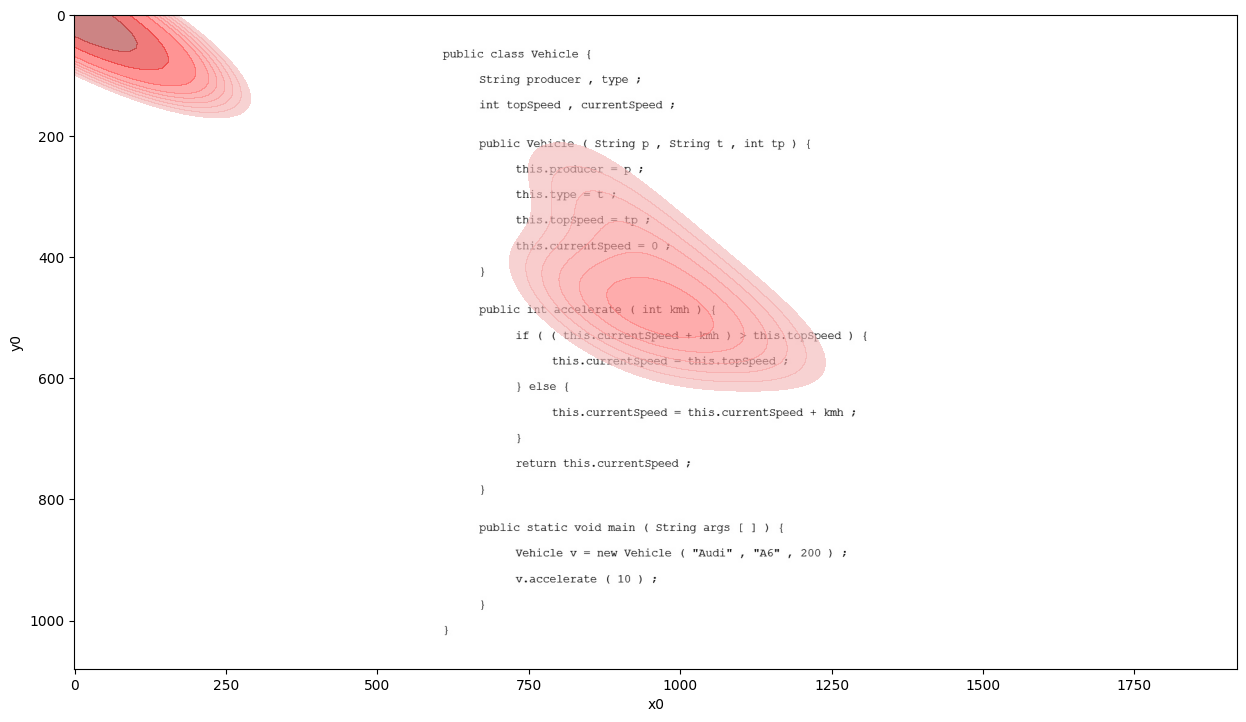

In [11]:
visualization.heatmap(trial_data)

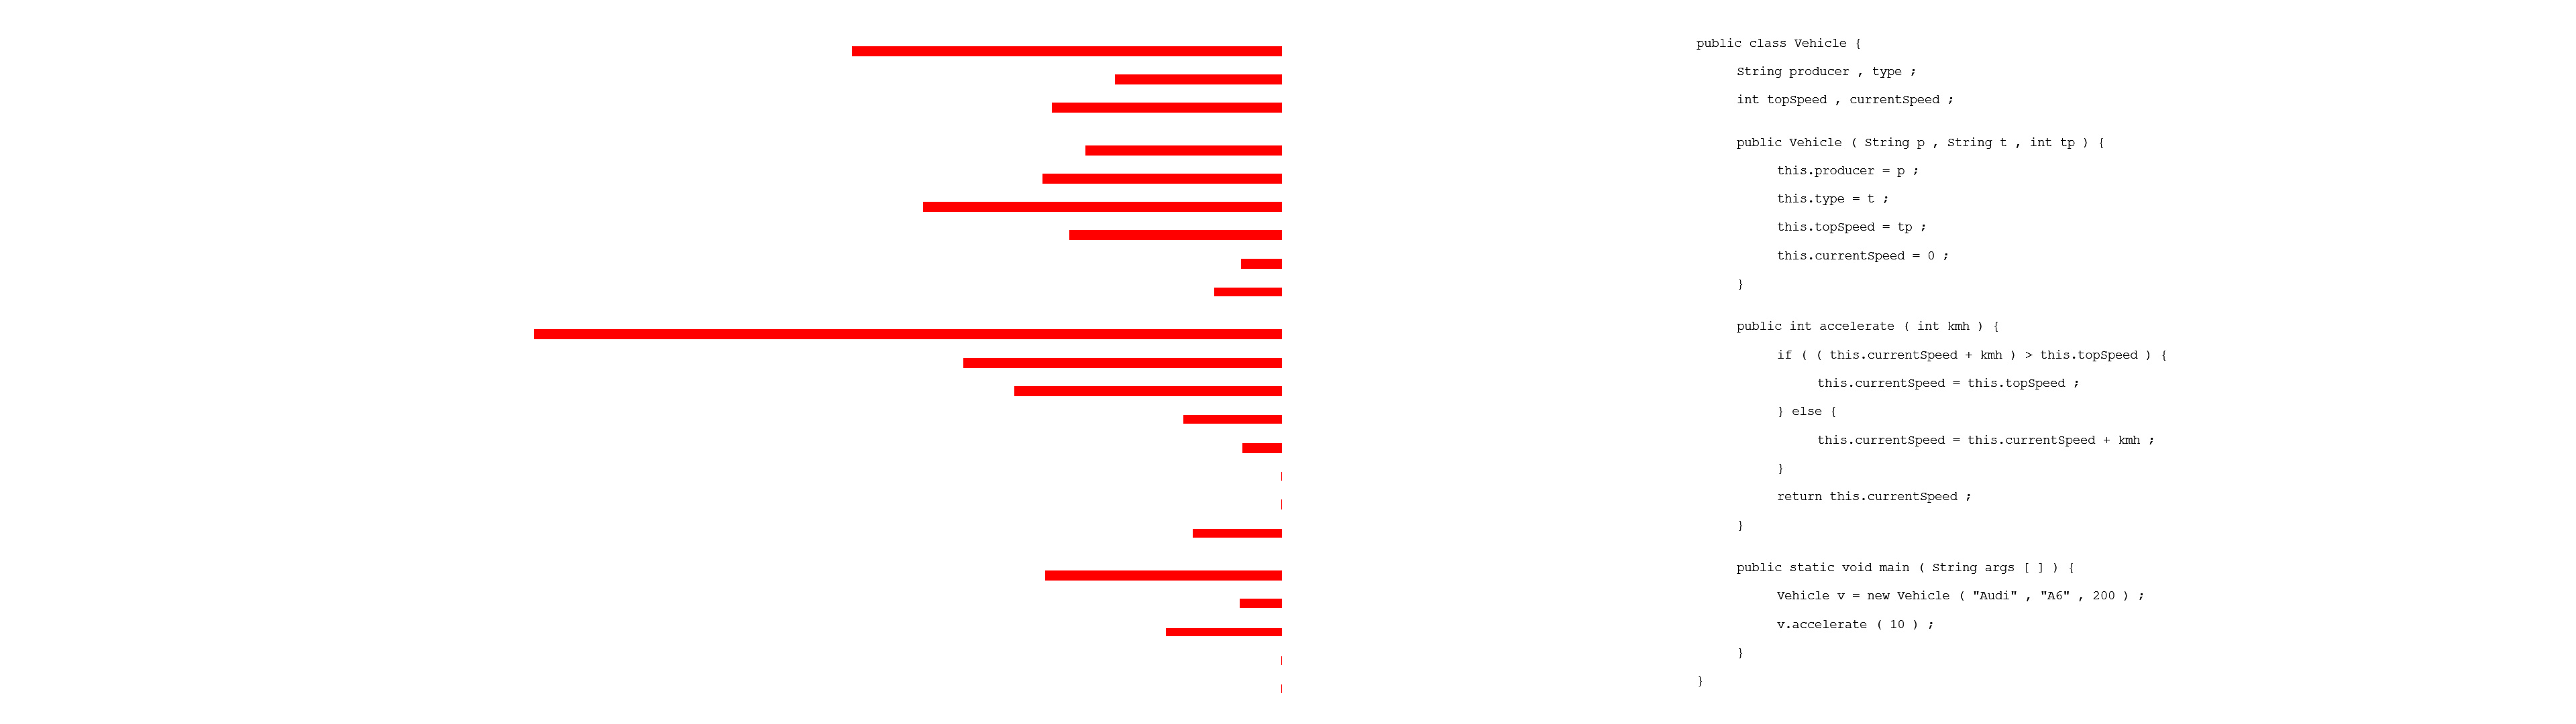

In [12]:
visualization.fixation_duration(trial_data)

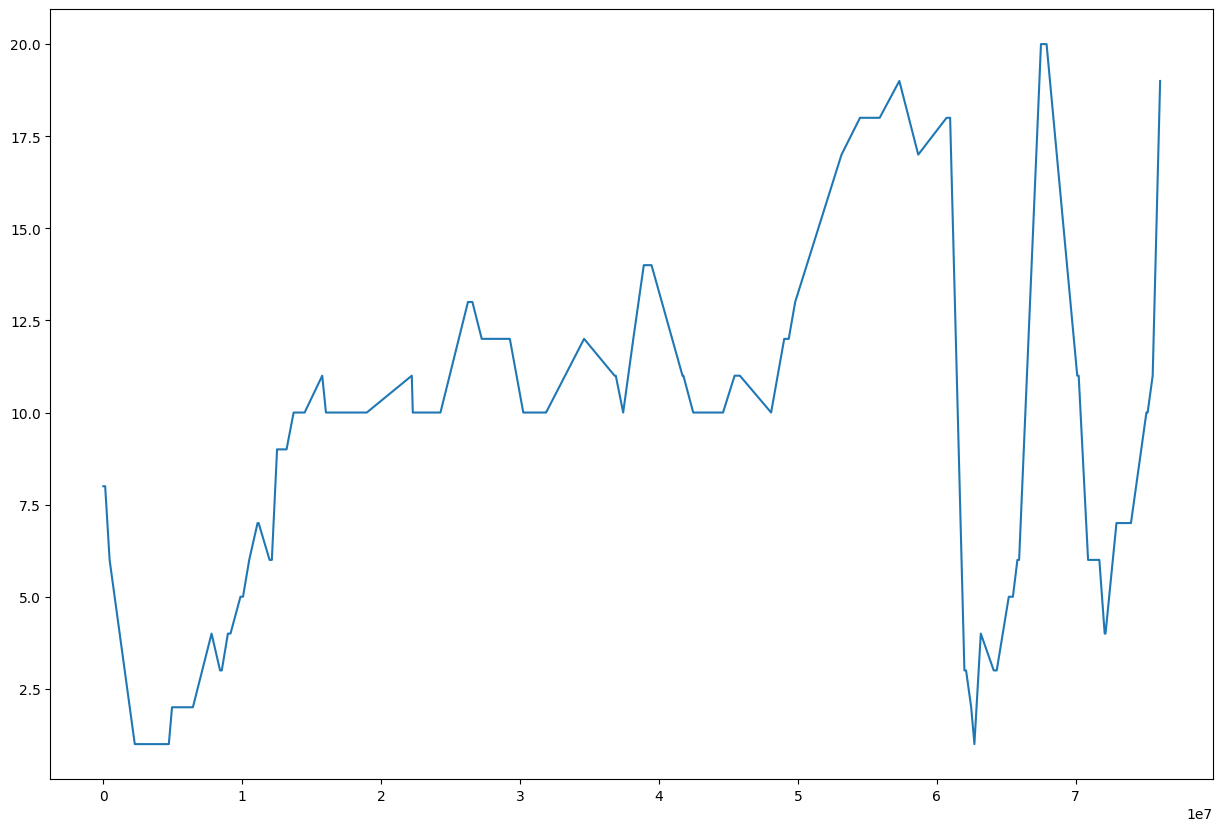

In [13]:
visualization.fixation_timeline(trial_data)


# Fixation correction through setting offset

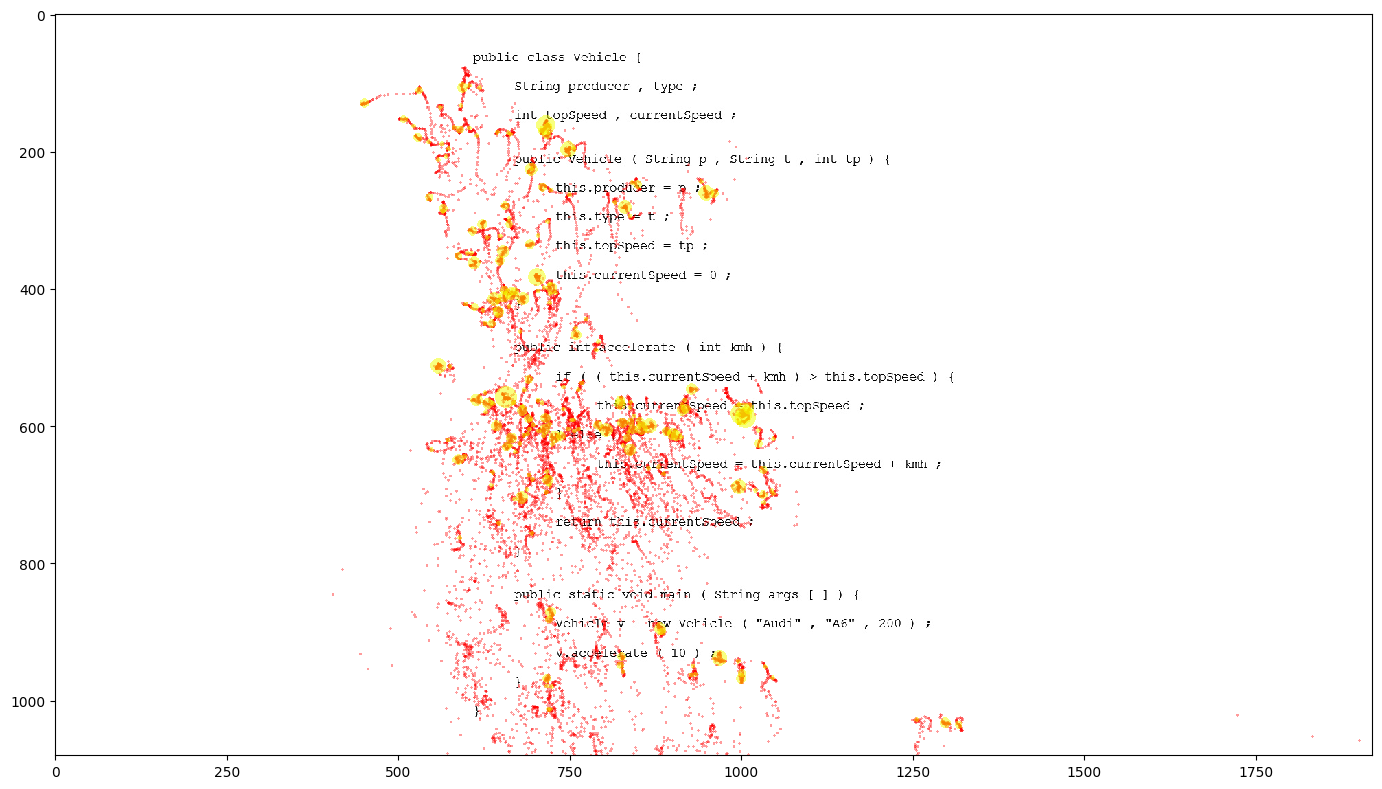

In [14]:
trial_data_copy = util.sample_offset(trial_data, -200, 100)
samples_copy = util.sample_offset(samples_data, -200, 100, x0_col='R POR X [px]', y0_col='R POR Y [px]')
visualization.draw_trial(trial_data_copy, samples_copy, draw_raw_data = True,
                        sample_x_col='R POR X [px]', sample_y_col='R POR Y [px]')

# Generate AOIs for a stimuli

In [15]:
aoi_df = aoi.find_aoi(trial_data)
aoi_df.head()
print(aoi_df)

         kind            name      x     y  width  height             image
0    sub-line   line 1 part 1  606.5    54     73      24  vehicle_java.jpg
1    sub-line   line 1 part 2  686.5    54     59      24  vehicle_java.jpg
2    sub-line   line 1 part 3  752.5    54     83      24  vehicle_java.jpg
3    sub-line   line 1 part 4  845.5    54     10      24  vehicle_java.jpg
4    sub-line   line 2 part 1  667.5    96     72      24  vehicle_java.jpg
..        ...             ...    ...   ...    ...     ...               ...
107  sub-line  line 20 part 3  896.5   922     25      21  vehicle_java.jpg
108  sub-line  line 20 part 4  930.5   922     10      21  vehicle_java.jpg
109  sub-line  line 20 part 5  953.5   922     11      21  vehicle_java.jpg
110  sub-line  line 21 part 1  669.5   964     11      22  vehicle_java.jpg
111  sub-line  line 22 part 1  609.5  1006     11      22  vehicle_java.jpg

[112 rows x 7 columns]


# Add text tokens to generated AOIs

In [16]:
file_path = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/EMIP_DataCollection_Materials/emip_stimulus_programs/"
aois_with_tokens = aoi.add_tokens_to_AOIs(file_path, aoi_df)
aois_with_tokens.head()

,kind,name,x,y,width,height,image,token
0,sub-line,line 1 part 1,606.5,54,73,24,vehicle_java.jpg,public
1,sub-line,line 1 part 2,686.5,54,59,24,vehicle_java.jpg,class
2,sub-line,line 1 part 3,752.5,54,83,24,vehicle_java.jpg,Vehicle
3,sub-line,line 1 part 4,845.5,54,10,24,vehicle_java.jpg,{
4,sub-line,line 2 part 1,667.5,96,72,24,vehicle_java.jpg,String


# Add srcML tags to AOIs with token

__Prerequisite__: In order to match the tokens with the AOI, make sure you have the EMIP2021 folder inside the datasets folder:
```
- emtk
    - datasets
        - EMIP2021
            - rectangle.tsv
            - vehicle.tsv
```

The srcML format is an XML representation for source code, where the markup tags identify elements of the abstract syntax for the language. Read more about it: https://www.srcml.org/about.html

In [17]:
srcML_path = "emtk/datasets/EMIP2021/"
aois_tokens_srcml = aoi.add_srcml_to_AOIs(aois_with_tokens, srcML_path)
aois_tokens_srcml.head()

,kind,name,x,y,width,height,image,token,srcML_tag
0,sub-line,line 1 part 1,606.5,54,73,24,vehicle_java.jpg,public,class->specifier
1,sub-line,line 1 part 2,686.5,54,59,24,vehicle_java.jpg,class,class
2,sub-line,line 1 part 3,752.5,54,83,24,vehicle_java.jpg,Vehicle,class->name
3,sub-line,line 1 part 4,845.5,54,10,24,vehicle_java.jpg,{,class->block
4,sub-line,line 2 part 1,667.5,96,72,24,vehicle_java.jpg,String,class->block->decl_stmt->decl->type->name


# Perform hit test between fixation and AOIs

Match fixations to AOIs to calculate the fixation duration over each AOI (can be customized for line or code token). Radius is 25 pixels by default and it represents the area around the AOI included in the AOI region.

In [18]:
trial_data_fixation = trial_data.loc[trial_data['eye_event_type'] == 'fixation']

aoi_fixations = aoi.hit_test(trial_data_fixation, aois_tokens_srcml, radius = 25)
aoi_fixations.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1020767309,84,861.736667,327.922381,sub-line,line 7 part 1,727.5,328,150,24,this.topSpeed,class->block->constructor->block->block_conten...
1,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1020867339,96,863.951250,309.950833,sub-line,line 6 part 3,861.5,286,15,24,t,class->block->constructor->block->block_conten...
2,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1022858994,76,781.798421,66.571579,sub-line,line 1 part 3,752.5,54,83,24,Vehicle,class->name
3,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1023355043,60,722.467333,64.309333,sub-line,line 1 part 2,686.5,54,59,24,class,class
4,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1023467040,108,707.782593,54.489630,sub-line,line 1 part 2,686.5,54,59,24,class,class


In [39]:
temp_df = corrected_df[(corrected_df['participant'] == 1) & (corrected_df['code_file'] == 'vehicle_java.jpg') & (corrected_df['timestamp'] == 1020767309)]

temp_df.head()

,Unnamed: 0,trial,participant,code_file,code_language,timestamp,duration,x_cord,y_cord,aoi_x,aoi_y,aoi_width,aoi_height,token,length,srcML,quality,line,part,gender
1556,1556,2,1,vehicle_java.jpg,vehicle_java.jpg,1020767309,84,836.736667,377.922381,732,374,189,18,this.currentSpeed,17,class->block->constructor->block->block_conten...,65,8,1,male


In [40]:
temp_df = trial_data[trial_data['timestamp'] == 1020767309]

temp_df.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,x1,y1,token,pupil,amplitude,peak_velocity,eye_event_type,gender
52,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1020767309,84,861.736667,327.922381,NaN,NaN,"[1097998216, MSG, 1, # Message: mupliple_choic...",0,NaN,NaN,fixation,male


In [41]:
temp_df = aoi_fixations[aoi_fixations['timestamp'] == 1020767309]

temp_df.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token,aoi_srcML_tag
0,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1020767309,84,861.736667,327.922381,sub-line,line 7 part 1,727.5,328,150,24,this.topSpeed,class->block->constructor->block->block_conten...


In [42]:
temp_df = eye_events[eye_events['timestamp'] == 1020767309]

temp_df.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,x1,y1,token,pupil,amplitude,peak_velocity,eye_event_type,gender
52,SMIRed250,1,1,1_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,1020767309,84,861.736667,327.922381,NaN,NaN,"[1097998216, MSG, 1, # Message: mupliple_choic...",0,NaN,NaN,fixation,male
